In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

recipes = pd.read_csv('../data/recipes_cleaned.csv')
print('Shape:', recipes.shape)

Shape: (83782, 20)


In [3]:
# Identifying missing values
missing = recipes.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print('\nMissing %:')
print((missing / len(recipes) * 100).round(2))

Columns with missing values:
name              1
description      70
avg_rating     2609
dtype: int64

Missing %:
name           0.00
description    0.08
avg_rating     3.11
dtype: float64


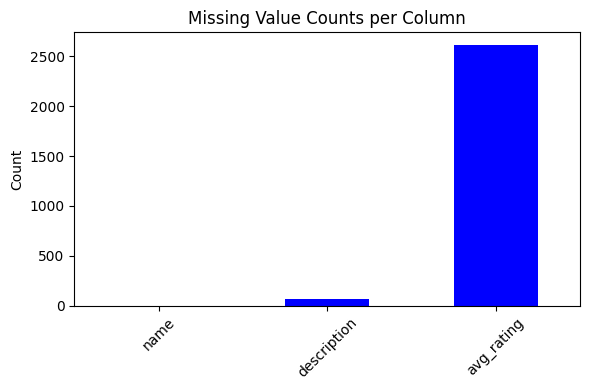

In [4]:
# Visualization of missing values
plt.figure(figsize=(6, 4))
missing.plot(kind='bar', color='blue')
plt.title('Missing Value Counts per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_counts.png')
plt.show()

In [ ]:
# Null hypothesis: Distribution of 'minutes' is the same whether 'avg_rating' is missing or not.

In [5]:
recipes['rating_missing'] = recipes['avg_rating'].isnull()

In [6]:
# Difference in means
missing_minutes = recipes[recipes['rating_missing']]['minutes']
not_missing_minutes = recipes[~recipes['rating_missing']]['minutes']
observed_diff = missing_minutes.mean() - not_missing_minutes.mean()
print(f'Observed difference in minutes means: {observed_diff:.2f}')

Observed difference in minutes means: 117.34


In [7]:
# Permutation test
np.random.seed(42)
n_permutations = 1000
perm_diffs = []

for _ in range(n_permutations):
    shuffled = recipes['rating_missing'].sample(frac=1).reset_index(drop=True)
    diff = recipes[shuffled]['minutes'].mean() - recipes[~shuffled]['minutes'].mean()
    perm_diffs.append(diff)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'P-value: {p_value:.4f}')

P-value: 0.0380


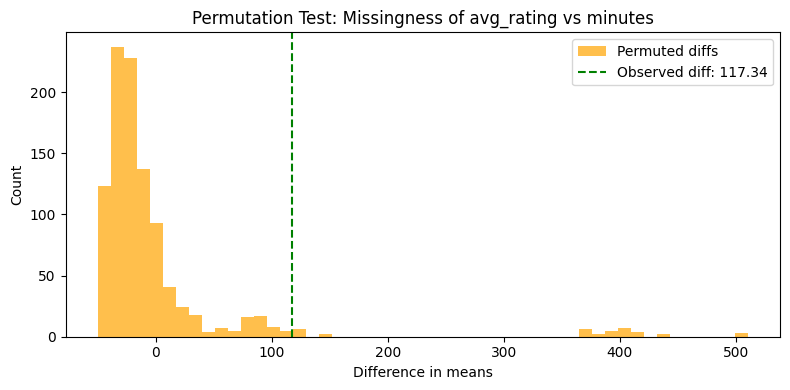

In [8]:
# Visualization of permutation distribution

plt.figure(figsize=(8, 4))
plt.hist(perm_diffs, bins=50, color='orange', alpha=0.7, label='Permuted diffs')
plt.axvline(observed_diff, color='green', linestyle='--', label=f'Observed diff: {observed_diff:.2f}')
plt.title('Permutation Test: Missingness of avg_rating vs minutes')
plt.xlabel('Difference in means')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('permutation_test_minutes.png')
plt.show()

Observed difference in n_ingredients means: 0.25
P-value: 0.0000


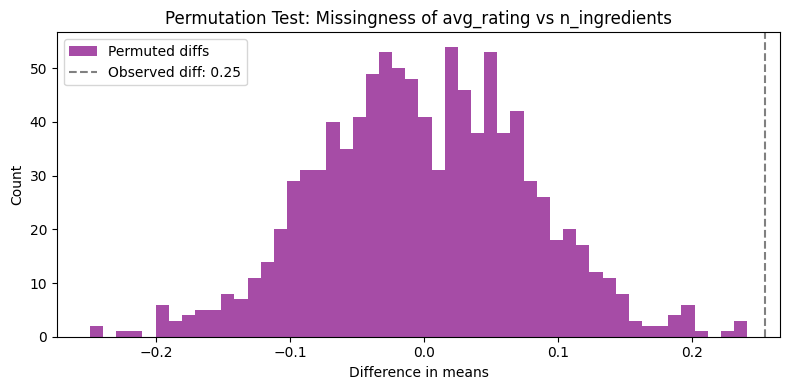

In [ ]:
# Testing againt 'n_ingredients' (does missingness of avg_rating depend on n_ingredients?)
missing_ingr = recipes[recipes['rating_missing']]['n_ingredients']
not_missing_ingr = recipes[~recipes['rating_missing']]['n_ingredients']
observed_diff2 = missing_ingr.mean() - not_missing_ingr.mean()

perm_diffs2 = []
for _ in range(n_permutations):
    shuffled = recipes['rating_missing'].sample(frac=1).reset_index(drop=True)
    diff = recipes[shuffled]['n_ingredients'].mean() - recipes[~shuffled]['n_ingredients'].mean()
    perm_diffs2.append(diff)

p_value2 = np.mean(np.abs(perm_diffs2) >= np.abs(observed_diff2))
print(f'Observed difference in n_ingredients means: {observed_diff2:.2f}')
print(f'P-value: {p_value2:.4f}')

plt.figure(figsize=(8, 4))
plt.hist(perm_diffs2, bins=50, color='purple', alpha=0.7, label='Permuted diffs')
plt.axvline(observed_diff2, color='gray', linestyle='--', label=f'Observed diff: {observed_diff2:.2f}')
plt.title('Permutation Test: Missingness of avg_rating vs n_ingredients')
plt.xlabel('Difference in means')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('permutation_test_ingredients.png')
plt.show()

In [ ]:
## Conclusions ##
#1. minutes vs missingness of avg_rating; p-value = 0.038
    # p < 0.05, reject null hypothesis
    # recipes with missing ratings tend to have different cooking times than rated recipes
    # Key insight: MAR with respect to minutes
#2. n_ingredients vs missingness of avg_rating — p-value ≈ 0.000
    # very strong dependency
    # recipes with fewer ingredients are more likey to have missing ratings
    # Key insight: MAR with respect to n_ingredients
# Overall, avg_rating is likely NMAR on its own (unpopular recipes didn't get rated), but it is also MAR with respect to minutes and n_ingrediets; which indicates that simpler and faster recipes tend to have missing ratings more often. 